<a href="https://colab.research.google.com/github/ZadeedSwin/HNR-COS30018/blob/main/HandwrittenNumberRecog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load data (60k training images, 10k test images of digits 0-9)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Preprocess: scale pixels to 0-1 and add a channel dimension
x_train = x_train[..., None] / 255.0
x_test  = x_test[..., None] / 255.0

# 3. Build the model (architecture)
model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')   # 10 classes = digits 0-9
])

# 4. Compile: choose optimiser, loss and metric
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# 6. Evaluate on unseen data
model.evaluate(x_test, y_test)

# 7. Save it for your app later
model.save('digit_cnn.keras')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9449 - loss: 0.1814 - val_accuracy: 0.9780 - val_loss: 0.0722
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9812 - loss: 0.0621 - val_accuracy: 0.9892 - val_loss: 0.0419
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9867 - loss: 0.0435 - val_accuracy: 0.9907 - val_loss: 0.0321
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9898 - loss: 0.0347 - val_accuracy: 0.9903 - val_loss: 0.0336
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9911 - loss: 0.0275 - val_accuracy: 0.9877 - val_loss: 0.0432
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9888 - loss: 0.0360


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


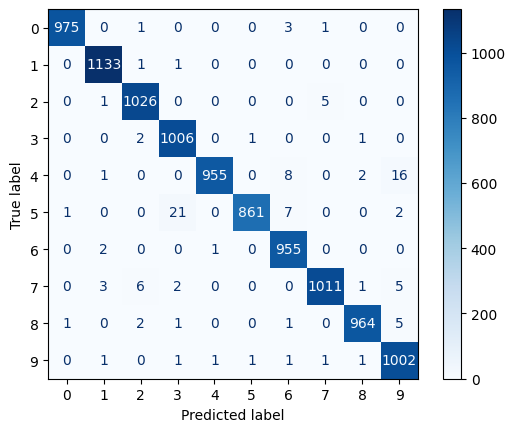

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.97      1.00      0.99      1010
           4       1.00      0.97      0.99       982
           5       1.00      0.97      0.98       892
           6       0.98      1.00      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.97      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



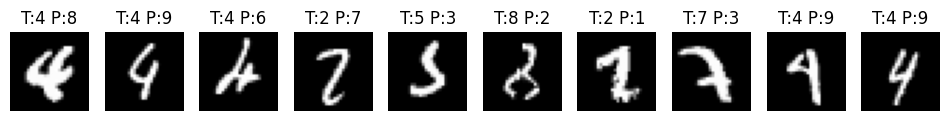

In [2]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

pred = model.predict(x_test).argmax(axis=1)

# Confusion matrix: which digits get confused with which
ConfusionMatrixDisplay(confusion_matrix(y_test, pred)).plot(cmap='Blues')
plt.show()

# Precision / recall per digit
print(classification_report(y_test, pred))

# Show 10 wrong predictions
wrong = np.where(pred != y_test)[0][:10]
plt.figure(figsize=(12, 3))
for i, idx in enumerate(wrong):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"T:{y_test[idx]} P:{pred[idx]}")
    plt.axis('off')
plt.show()

In [3]:
from tensorflow.keras import callbacks

model2 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    # Data augmentation (only active during training)
    layers.RandomRotation(0.08),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),

    layers.Conv2D(32, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

early = callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                restore_best_weights=True)

history = model2.fit(x_train, y_train, epochs=20,
                     validation_split=0.1, callbacks=[early])

model2.evaluate(x_test, y_test)
model2.save('digit_cnn_v2.keras')

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8660 - loss: 0.4281 - val_accuracy: 0.9725 - val_loss: 0.0985
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9423 - loss: 0.1959 - val_accuracy: 0.9630 - val_loss: 0.1333
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9529 - loss: 0.1620 - val_accuracy: 0.9793 - val_loss: 0.0731
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9592 - loss: 0.1401 - val_accuracy: 0.9852 - val_loss: 0.0564
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9637 - loss: 0.1263 - val_accuracy: 0.9813 - val_loss: 0.0690
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9670 - loss: 0.1152 - val_accuracy: 0.9865 - val_loss: 0.0502
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9691 - loss: 0.1085 - val_accuracy: 0.9770 - val_loss: 0.0739
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9719 - loss: 0

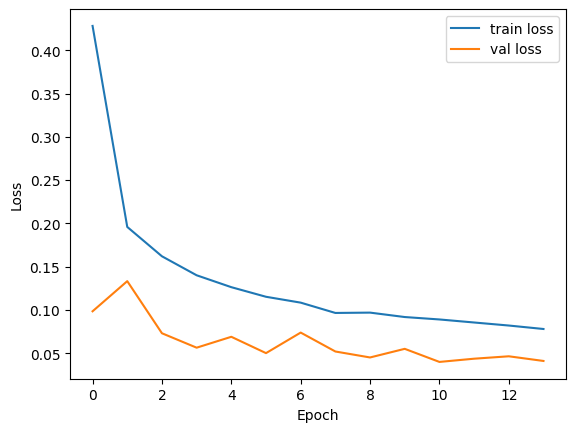

SVM accuracy: 0.9594
Time: 34.2s


In [4]:
# 1. Learning curves for model2
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

# 2. SVM baseline (classic ML, not deep learning)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

Xtr = x_train.reshape(len(x_train), -1)[:10000]   # 10k samples to keep it fast
Ytr = y_train[:10000]
Xte = x_test.reshape(len(x_test), -1)

start = time.time()
svm = SVC(kernel='rbf')
svm.fit(Xtr, Ytr)
svm_pred = svm.predict(Xte)
print(f"SVM accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"Time: {time.time()-start:.1f}s")

In [5]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np

uploaded = files.upload()
fname = list(uploaded.keys())[0]

img = Image.open(fname).convert('L')          # grayscale
img = ImageOps.invert(img)                    # MNIST = white digit on black
img = img.point(lambda p: 255 if p > 100 else 0)   # remove background noise
img = img.crop(img.getbbox())                 # crop to the digit

# Fit into a 20x20 box, then centre it on a 28x28 image (same as MNIST)
img.thumbnail((20, 20))
canvas = Image.new('L', (28, 28), 0)
canvas.paste(img, ((28 - img.width) // 2, (28 - img.height) // 2))

x = np.array(canvas)[None, ..., None] / 255.0
plt.imshow(x.squeeze(), cmap='gray'); plt.axis('off'); plt.show()

for name, m in [('CNN v1', model), ('CNN v2', model2)]:
    p = m.predict(x, verbose=0)[0]
    print(f"{name}: predicted {p.argmax()} ({p.max()*100:.1f}% confident)")

KeyboardInterrupt: 

In [6]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/YOUR_FILE.zip" -d /content/dataset
!ls /content/dataset
!find /content/dataset -name "*.csv"

Mounted at /content/drive
unzip:  cannot find or open /content/drive/MyDrive/YOUR_FILE.zip, /content/drive/MyDrive/YOUR_FILE.zip.zip or /content/drive/MyDrive/YOUR_FILE.zip.ZIP.
ls: cannot access '/content/dataset': No such file or directory
find: ‘/content/dataset’: No such file or directory


In [7]:
from google.colab import drive
drive.mount('/content/drive')

# Install the RAR extractor
!apt-get -qq install -y unrar > /dev/null

# Find the file in your Drive
!find /content/drive/MyDrive -name "handwritten_numbers_v1.rar"

# Extract it
!mkdir -p /content/dataset
!unrar x -o+ -inul "/content/drive/MyDrive/handwritten_numbers_v1.rar" /content/dataset/

# Look inside
!ls /content/dataset
!find /content/dataset -maxdepth 2 -type d
!find /content/dataset -name "*.csv" -o -name "*.txt"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/handwritten_numbers_v1.rar
0.png	  2287.png  3573.png  485.png	6145.png  7431.png  8718.png
1000.png  2288.png  3574.png  4860.png	6146.png  7432.png  8719.png
1001.png  2289.png  3575.png  4861.png	6147.png  7433.png  871.png
1002.png  228.png   3576.png  4862.png	6148.png  7434.png  8720.png
1003.png  2290.png  3577.png  4863.png	6149.png  7435.png  8721.png
1004.png  2291.png  3578.png  4864.png	614.png   7436.png  8722.png
1005.png  2292.png  3579.png  4865.png	6150.png  7437.png  8723.png
1006.png  2293.png  357.png   4866.png	6151.png  7438.png  8724.png
1007.png  2294.png  3580.png  4867.png	6152.png  7439.png  8725.png
1008.png  2295.png  3581.png  4868.png	6153.png  743.png   8726.png
1009.png  2296.png  3582.png  4869.png	6154.png  7440.png  8727.png
100.png   2297.png  3583.png  486.png	6155.png  7441.png  8728.png
1010.png  

(0, 10000)
Empty DataFrame
Columns: [16, 1, 9, 7, 4, 4.1, 2, 4.2, 1.1, 1.2, 280, 120, 83, 95, 82, 56, 60, 30, 9.1, 6, 3, 9.2, 7.1, 281, 0, 136, 86, 82.1, 67, 54, 73, 40, 7.2, 4.3, 5, 0.1, 6.1, 2.1, 0.2, 0.3, 114, 74, 95.1, 76, 56.1, 63, 42, 6.2, 5.1, 3.1, 0.4, 7.3, 4.4, 1.3, 272, 127, 34, 4.5, 0.5, 3.2, 0.6, 2.2, 5.2, 0.7, 0.8, 102, 76.1, 56.2, 68, 58, 39, 5.3, 5.4, 0.9, 11, 6.3, 0.10, 1.4, 111, 77, 80, 70, 58.1, 52, 36, 11.1, 5.5, 4.6, 1.5, 9.3, 3.3, 1.6, 241, 0.11, 77.1, 2.3, 1.7, 3.4, 4.7, 6.4, ...]
Index: []

[0 rows x 10000 columns]
16       object
1        object
9        object
7        object
4        object
          ...  
8.277    object
1.232    object
3.386    object
6.395    object
1.233    object
Length: 10000, dtype: object


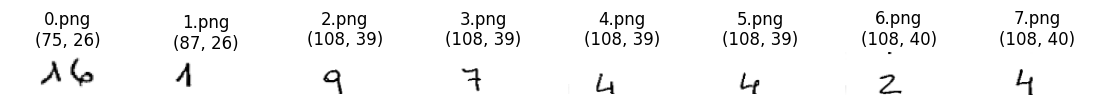

In [8]:
import pandas as pd
from PIL import Image

df = pd.read_csv('/content/dataset/labels.csv')
print(df.shape)          # rows, columns
print(df.head(10))       # first 10 rows
print(df.dtypes)

# Show the first 8 images with their size
plt.figure(figsize=(14, 3))
for i in range(8):
    fname = f'/content/dataset/{i}.png'
    img = Image.open(fname)
    plt.subplot(1, 8, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{i}.png\n{img.size}")
    plt.axis('off')
plt.show()

10000 ['16', '1', '9', '7', '4', '4', '2', '4']
Total digits found: 19476
Segmentation accuracy (correct digit count): 0.7883
CNN v1: exact-match accuracy = 0.6463
CNN v2: exact-match accuracy = 0.6204


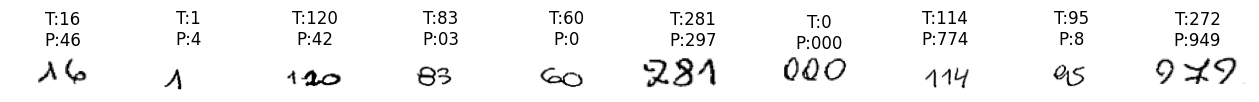

In [9]:
import cv2
import numpy as np, pandas as pd

# 1. Load labels correctly (one row -> list of strings)
labels = pd.read_csv('/content/dataset/labels.csv', header=None, dtype=str).iloc[0].tolist()
print(len(labels), labels[:8])   # expect: 10000 ['16', '1', '9', '7', '4', '4', '2', '4']

# 2. Segmentation: split an image into single MNIST-style digits
def segment(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    # Otsu threshold + invert -> white digit on black (like MNIST)
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find separate ink blobs (connected components)
    n, _, stats, _ = cv2.connectedComponentsWithStats(th, connectivity=8)
    if n <= 1:
        return []
    areas = stats[1:, 4]
    min_area = max(10, 0.05 * areas.max())          # ignore dots / noise
    boxes = [list(stats[i][:4]) for i in range(1, n) if stats[i][4] >= min_area]
    boxes.sort(key=lambda b: b[0])                   # left to right

    # Merge blobs that overlap horizontally (e.g. a '4' drawn in two strokes)
    merged = []
    for b in boxes:
        if merged:
            m = merged[-1]
            overlap = min(m[0]+m[2], b[0]+b[2]) - max(m[0], b[0])
            if overlap > 0.5 * min(m[2], b[2]):
                x1, y1 = min(m[0], b[0]), min(m[1], b[1])
                x2, y2 = max(m[0]+m[2], b[0]+b[2]), max(m[1]+m[3], b[1]+b[3])
                merged[-1] = [x1, y1, x2-x1, y2-y1]
                continue
        merged.append(b)

    # Resize each digit into a 20x20 box, centred on a 28x28 image
    digits = []
    for x, y, w, h in merged:
        crop = th[y:y+h, x:x+w]
        s = 20 / max(w, h)
        crop = cv2.resize(crop, (max(1, int(w*s)), max(1, int(h*s))), interpolation=cv2.INTER_AREA)
        canvas = np.zeros((28, 28), np.uint8)
        ch, cw = crop.shape
        canvas[(28-ch)//2:(28-ch)//2+ch, (28-cw)//2:(28-cw)//2+cw] = crop
        digits.append(canvas)
    return digits

# 3. Segment all 10,000 images
all_digits, owners, counts = [], [], []
for i in range(len(labels)):
    ds = segment(f'/content/dataset/{i}.png')
    all_digits += ds
    owners += [i] * len(ds)
    counts.append(len(ds))
X = np.array(all_digits)[..., None] / 255.0
print("Total digits found:", len(X))

# 4. Predict all digits at once, then join them back into numbers
def evaluate(m, name):
    preds = m.predict(X, batch_size=512, verbose=0).argmax(1)
    results = [''] * len(labels)
    for o, p in zip(owners, preds):
        results[o] += str(p)
    exact = np.mean([r == l for r, l in zip(results, labels)])
    print(f"{name}: exact-match accuracy = {exact:.4f}")
    return results

seg_ok = np.mean([c == len(l) for c, l in zip(counts, labels)])
print(f"Segmentation accuracy (correct digit count): {seg_ok:.4f}")
res1 = evaluate(model, "CNN v1")
res2 = evaluate(model2, "CNN v2")

# 5. Show 10 failures from CNN v2
wrong = [i for i in range(len(labels)) if res2[i] != labels[i]][:10]
plt.figure(figsize=(16, 3))
for k, i in enumerate(wrong):
    plt.subplot(1, 10, k+1)
    plt.imshow(cv2.imread(f'/content/dataset/{i}.png', 0), cmap='gray')
    plt.title(f"T:{labels[i]}\nP:{res2[i]}")
    plt.axis('off')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# 1. Split IMAGES (not digits) into train/test
idx = np.arange(len(labels))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)

# Group segmented digits by image
digits_by_img = {}
for d, o in zip(all_digits, owners):
    digits_by_img.setdefault(o, []).append(d)

# 2. Build a digit dataset from training images where segmentation is correct
Xf, yf = [], []
for i in train_idx:
    ds = digits_by_img.get(i, [])
    if labels[i].isdigit() and len(ds) == len(labels[i]):
        Xf += ds
        yf += [int(c) for c in labels[i]]
Xf = np.array(Xf)[..., None] / 255.0
yf = np.array(yf)
print("Fine-tuning digits:", Xf.shape)

# 3. Fine-tune a copy of model2 with a small learning rate
ft = tf.keras.models.clone_model(model2)
ft.set_weights(model2.get_weights())
ft.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
           loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ft.fit(Xf, yf, epochs=15, validation_split=0.1, callbacks=[early])
ft.save('digit_cnn_finetuned.keras')

# 4. Compare all models on the SAME held-out test images
def evaluate_on(m, idxs, name):
    preds = m.predict(X, batch_size=512, verbose=0).argmax(1)
    results = [''] * len(labels)
    for o, p in zip(owners, preds):
        results[o] += str(p)
    acc = np.mean([results[i] == labels[i] for i in idxs])
    print(f"{name}: exact-match on test images = {acc:.4f}")
    return results

seg_test = np.mean([counts[i] == len(labels[i]) for i in test_idx])
print(f"Segmentation accuracy on test images (upper limit): {seg_test:.4f}")
evaluate_on(model,  test_idx, "CNN v1")
evaluate_on(model2, test_idx, "CNN v2")
res_ft = evaluate_on(ft, test_idx, "CNN fine-tuned")

Fine-tuning digits: (10914, 28, 28, 1)
Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.8980 - loss: 0.4581 - val_accuracy: 0.9203 - val_loss: 0.3878
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9252 - loss: 0.3284 - val_accuracy: 0.9386 - val_loss: 0.2845
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9353 - loss: 0.2878 - val_accuracy: 0.9423 - val_loss: 0.2550
Segmentation accuracy on test images (upper limit): 0.7815
CNN v1: exact-match on test images = 0.6455
CNN v2: exact-match on test images = 0.6135
CNN fine-tuned: exact-match on test images = 0.6915


In [11]:
early_ft = callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                   restore_best_weights=True)

ft.fit(Xf, yf, epochs=20, validation_split=0.1, callbacks=[early_ft])
ft.save('digit_cnn_finetuned.keras')

res_ft = evaluate_on(ft, test_idx, "CNN fine-tuned (full)")

Epoch 1/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9250 - loss: 0.3307 - val_accuracy: 0.9451 - val_loss: 0.2735
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9371 - loss: 0.2674 - val_accuracy: 0.9505 - val_loss: 0.2375
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9394 - loss: 0.2571 - val_accuracy: 0.9515 - val_loss: 0.2211
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9451 - loss: 0.2342 - val_accuracy: 0.9551 - val_loss: 0.2064
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9486 - loss: 0.2180 - val_accuracy: 0.9588 - val_loss: 0.1976
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9493 - loss: 0.2162 - val_accuracy: 0.9625 - val_loss: 0.1890
Epoch 7/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9498 - loss: 0.2058 - val_accuracy: 0.9661 - val_loss: 0.1756
Epoch 8/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9526 - loss: 0.1981 - val_accuracy: 

In [12]:
def to_mnist(crop):
    ys, xs = np.nonzero(crop)
    if len(xs) == 0:
        return None
    crop = crop[ys.min():ys.max()+1, xs.min():xs.max()+1]
    h, w = crop.shape
    s = 20 / max(w, h)
    crop = cv2.resize(crop, (max(1, int(w*s)), max(1, int(h*s))), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((28, 28), np.uint8)
    ch, cw = crop.shape
    canvas[(28-ch)//2:(28-ch)//2+ch, (28-cw)//2:(28-cw)//2+cw] = crop
    return canvas

def segment2(path, merge_thr=0.5, ratio=None):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    n, _, stats, _ = cv2.connectedComponentsWithStats(th, 8)
    if n <= 1:
        return []
    areas = stats[1:, 4]
    min_area = max(10, 0.05 * areas.max())
    boxes = sorted([list(stats[i][:4]) for i in range(1, n) if stats[i][4] >= min_area],
                   key=lambda b: b[0])

    # Merge horizontally overlapping blobs
    merged = []
    for b in boxes:
        if merged:
            m = merged[-1]
            overlap = min(m[0]+m[2], b[0]+b[2]) - max(m[0], b[0])
            if overlap > merge_thr * min(m[2], b[2]):
                x1, y1 = min(m[0], b[0]), min(m[1], b[1])
                x2, y2 = max(m[0]+m[2], b[0]+b[2]), max(m[1]+m[3], b[1]+b[3])
                merged[-1] = [x1, y1, x2-x1, y2-y1]
                continue
        merged.append(b)

    # Split blobs that are too wide (touching digits)
    pieces = []
    H = np.median([b[3] for b in merged])
    for x, y, w, h in merged:
        k = 1 if ratio is None else int(round(w / (ratio * H)))
        if k <= 1:
            pieces.append(th[y:y+h, x:x+w])
            continue
        col = th[y:y+h, x:x+w].sum(axis=0)       # ink per column
        cuts = [0]
        for j in range(1, k):
            c = int(j * w / k)
            r = max(1, w // (4 * k))
            lo, hi = max(1, c - r), min(w - 1, c + r)
            cuts.append(lo + int(np.argmin(col[lo:hi])) if hi > lo else c)
        cuts.append(w)
        for a, bnd in zip(cuts[:-1], cuts[1:]):
            if bnd - a > 1:
                pieces.append(th[y:y+h, x+a:x+bnd])

    return [d for d in (to_mnist(p) for p in pieces) if d is not None]

# 1. Tune settings on a sample of TRAINING images only
rng = np.random.default_rng(0)
tune_idx = rng.choice(train_idx, 2000, replace=False)
best = None
for merge_thr in [0.5, 0.8]:
    for ratio in [None, 0.9, 1.1, 1.3]:
        acc = np.mean([len(segment2(f'/content/dataset/{i}.png', merge_thr, ratio)) == len(labels[i])
                       for i in tune_idx])
        print(f"merge_thr={merge_thr}, ratio={ratio}: seg acc = {acc:.4f}")
        if best is None or acc > best[0]:
            best = (acc, merge_thr, ratio)
print("Best:", best)

# 2. Re-segment all images with the best settings
_, MT, RT = best
all_digits, owners, counts = [], [], []
for i in range(len(labels)):
    ds = segment2(f'/content/dataset/{i}.png', MT, RT)
    all_digits += ds
    owners += [i] * len(ds)
    counts.append(len(ds))
X = np.array(all_digits)[..., None] / 255.0

# 3. Diagnose remaining errors and evaluate on TEST images
few  = np.mean([counts[i] <  len(labels[i]) for i in test_idx])
many = np.mean([counts[i] >  len(labels[i]) for i in test_idx])
seg_test = np.mean([counts[i] == len(labels[i]) for i in test_idx])
print(f"Test seg acc: {seg_test:.4f} | too few: {few:.4f} | too many: {many:.4f}")
res_ft2 = evaluate_on(ft, test_idx, "CNN fine-tuned + better segmentation")

merge_thr=0.5, ratio=None: seg acc = 0.7850
merge_thr=0.5, ratio=0.9: seg acc = 0.7125
merge_thr=0.5, ratio=1.1: seg acc = 0.7800
merge_thr=0.5, ratio=1.3: seg acc = 0.7880
merge_thr=0.8, ratio=None: seg acc = 0.7630
merge_thr=0.8, ratio=0.9: seg acc = 0.6935
merge_thr=0.8, ratio=1.1: seg acc = 0.7585
merge_thr=0.8, ratio=1.3: seg acc = 0.7665
Best: (np.float64(0.788), 0.5, 1.3)
Test seg acc: 0.7815 | too few: 0.0120 | too many: 0.2065
CNN fine-tuned + better segmentation: exact-match on test images = 0.7510


In [21]:
def segment3(path, merge_thr=0.5, ratio=1.3, min_frac=0.05, dilate=0):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    find = th if dilate == 0 else cv2.dilate(th, np.ones((2*dilate+1, 2*dilate+1), np.uint8))
    n, _, stats, _ = cv2.connectedComponentsWithStats(find, 8)
    if n <= 1:
        return []
    areas = stats[1:, 4]
    min_area = max(10, min_frac * areas.max())
    boxes = sorted([list(stats[i][:4]) for i in range(1, n) if stats[i][4] >= min_area],
                   key=lambda b: b[0])
    if not boxes:
        return []
    Hmax = max(b[3] for b in boxes)
    boxes = [b for b in boxes if b[3] >= 0.35 * Hmax]   # drop dots, dashes, underlines

    merged = []
    for b in boxes:
        if merged:
            m = merged[-1]
            overlap = min(m[0]+m[2], b[0]+b[2]) - max(m[0], b[0])   # negative = gap
            if overlap > merge_thr * min(m[2], b[2]):
                x1, y1 = min(m[0], b[0]), min(m[1], b[1])
                x2, y2 = max(m[0]+m[2], b[0]+b[2]), max(m[1]+m[3], b[1]+b[3])
                merged[-1] = [x1, y1, x2-x1, y2-y1]
                continue
        merged.append(b)

    pieces = []
    H = np.median([b[3] for b in merged])
    for x, y, w, h in merged:
        k = int(round(w / (ratio * H)))
        if k <= 1:
            pieces.append(th[y:y+h, x:x+w])
            continue
        col = th[y:y+h, x:x+w].sum(axis=0)
        cuts = [0]
        for j in range(1, k):
            c = int(j * w / k)
            r = max(1, w // (4 * k))
            lo, hi = max(1, c - r), min(w - 1, c + r)
            cuts.append(lo + int(np.argmin(col[lo:hi])) if hi > lo else c)
        cuts.append(w)
        for a, bnd in zip(cuts[:-1], cuts[1:]):
            if bnd - a > 1:
                pieces.append(th[y:y+h, x+a:x+bnd])
    return [d for d in (to_mnist(p) for p in pieces) if d is not None]

print("segment3 updated. Best settings still:", best)

segment3 updated. Best settings still: (np.float64(0.839), 0.2, 0.3, 0)


Seg v3 (numeric match): numeric match on test images = 0.8925
Seg v4 + filter (numeric match): numeric match on test images = 0.8865


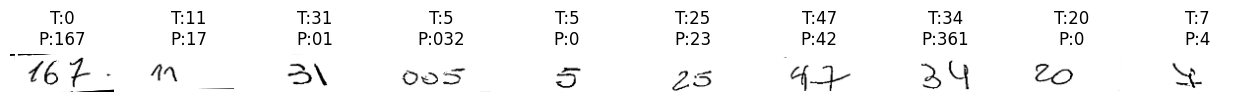

In [22]:
def to_num(s):
    try:
        return int(s)
    except ValueError:
        return None

def evaluate_num(m, idxs, name):
    preds = m.predict(X, batch_size=512, verbose=0).argmax(1)
    results = [''] * len(labels)
    for o, p in zip(owners, preds):
        results[o] += str(p)
    acc = np.mean([to_num(results[i]) is not None and to_num(results[i]) == to_num(labels[i])
                   for i in idxs])
    print(f"{name}: numeric match on test images = {acc:.4f}")
    return results

# 1. Score the current setup with numeric matching (fair comparison)
res_before = evaluate_num(ft, test_idx, "Seg v3 (numeric match)")

# 2. Re-segment all images with the dot/underline filter
_, MT, MF, DL = best
all_digits, owners, counts = [], [], []
for i in range(len(labels)):
    ds = segment3(f'/content/dataset/{i}.png', MT, 1.3, MF, DL)
    all_digits += ds; owners += [i] * len(ds); counts.append(len(ds))
X = np.array(all_digits)[..., None] / 255.0

res_v4 = evaluate_num(ft, test_idx, "Seg v4 + filter (numeric match)")

# 3. Show 10 remaining failures
wrong = [i for i in test_idx if to_num(res_v4[i]) != to_num(labels[i])][:10]
plt.figure(figsize=(16, 3))
for k, i in enumerate(wrong):
    plt.subplot(1, 10, k+1)
    plt.imshow(cv2.imread(f'/content/dataset/{i}.png', 0), cmap='gray')
    plt.title(f"T:{labels[i]}\nP:{res_v4[i]}")
    plt.axis('off')
plt.show()

In [23]:
# 1. Re-segment without the filter
all_digits, owners, counts = [], [], []
for i in range(len(labels)):
    ds = segment3(f'/content/dataset/{i}.png', MT, 1.3, MF, DL)
    all_digits += ds; owners += [i] * len(ds); counts.append(len(ds))
X = np.array(all_digits)[..., None] / 255.0
res_v3 = evaluate_num(ft, test_idx, "Seg v3 check")   # should be ~0.8925

# 2. Build a bigger fine-tuning set from TRAINING images
digits_by_img = {}
for d, o in zip(all_digits, owners):
    digits_by_img.setdefault(o, []).append(d)

Xf2, yf2 = [], []
for i in train_idx:
    ds, lab = digits_by_img.get(i, []), labels[i]
    if not lab.isdigit():
        continue
    extra = len(ds) - len(lab)
    if extra > 0 and res_v3[i][:extra] == '0' * extra:
        lab = lab.zfill(len(ds))          # restore leading zeros, e.g. 5 -> 005
    if len(ds) == len(lab):
        Xf2 += ds
        yf2 += [int(c) for c in lab]
Xf2 = np.array(Xf2)[..., None] / 255.0
yf2 = np.array(yf2)
print("Fine-tuning digits:", Xf2.shape, "(before: 10914)")

# 3. Fine-tune again, starting from ft
ft2 = tf.keras.models.clone_model(ft)
ft2.set_weights(ft.get_weights())
ft2.compile(optimizer=tf.keras.optimizers.Adam(5e-5),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early2 = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
ft2.fit(Xf2, yf2, epochs=20, validation_split=0.1, callbacks=[early2])
ft2.save('digit_cnn_finetuned_v2.keras')

res_ft2 = evaluate_num(ft2, test_idx, "CNN fine-tuned v2")


Seg v3 check: numeric match on test images = 0.8865
Fine-tuning digits: (13870, 28, 28, 1) (before: 10914)
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9535 - loss: 0.2119 - val_accuracy: 0.9712 - val_loss: 0.1639
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9563 - loss: 0.2003 - val_accuracy: 0.9712 - val_loss: 0.1587
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9568 - loss: 0.1997 - val_accuracy: 0.9712 - val_loss: 0.1543
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9567 - loss: 0.2021 - val_accuracy: 0.9726 - val_loss: 0.1489
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9560 - loss: 0.2043 - val_accuracy: 0.9740 - val_loss: 0.1471
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9543 - loss: 0.1928 - val_accuracy: 0.9726 - val_loss: 0.1462
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9543 - loss: 0.1941 - val_accuracy: 0.9719 - val_loss: 0

In [24]:
import inspect
print([l.strip() for l in inspect.getsource(segment3).splitlines() if 'Hmax' in l])

['Hmax = max(b[3] for b in boxes)', 'boxes = [b for b in boxes if b[3] >= 0.35 * Hmax]   # drop dots, dashes, underlines']


In [25]:
all_digits, owners, counts = [], [], []
for i in range(len(labels)):
    ds = segment3(f'/content/dataset/{i}.png', MT, 1.3, MF, DL)
    all_digits += ds; owners += [i] * len(ds); counts.append(len(ds))
X = np.array(all_digits)[..., None] / 255.0

evaluate_num(ft,  test_idx, "Fine-tuned v1")   # expect ~0.8925
evaluate_num(ft2, test_idx, "Fine-tuned v2")

Fine-tuned v1: numeric match on test images = 0.8865
Fine-tuned v2: numeric match on test images = 0.8885


['16',
 '1',
 '9',
 '7',
 '4',
 '4',
 '2',
 '4',
 '1',
 '1',
 '280',
 '20',
 '8',
 '95',
 '82',
 '56',
 '60',
 '30',
 '9',
 '6',
 '3',
 '9',
 '7',
 '281',
 '0',
 '136',
 '86',
 '82',
 '67',
 '54',
 '73',
 '40',
 '7',
 '4',
 '5',
 '0',
 '6',
 '2',
 '0',
 '000',
 '114',
 '74',
 '8',
 '76',
 '56',
 '63',
 '42',
 '6',
 '5',
 '3',
 '0',
 '7',
 '4',
 '1',
 '279',
 '127',
 '34',
 '04',
 '0',
 '3',
 '0',
 '2',
 '6',
 '63',
 '0',
 '12',
 '76',
 '56',
 '68',
 '58',
 '39',
 '5',
 '5',
 '0',
 '11',
 '6',
 '0',
 '1',
 '111',
 '74',
 '0',
 '6',
 '58',
 '52',
 '36',
 '11',
 '7',
 '4',
 '1',
 '11',
 '3',
 '1',
 '241',
 '0',
 '77',
 '2',
 '1',
 '3',
 '4',
 '6',
 '67',
 '143',
 '94',
 '57',
 '42',
 '61',
 '58',
 '61',
 '2',
 '3',
 '3',
 '267',
 '5',
 '5',
 '67',
 '140',
 '97',
 '66',
 '53',
 '41',
 '5',
 '5',
 '6',
 '0',
 '9',
 '6',
 '0',
 '0',
 '106',
 '80',
 '72',
 '0',
 '67',
 '22',
 '4',
 '4',
 '6',
 '0',
 '10',
 '5',
 '0',
 '211',
 '0',
 '123',
 '68',
 '48',
 '16',
 '34',
 '114',
 '6',
 '7',
 '0',


In [26]:
print([l.strip() for l in inspect.getsource(segment3).splitlines() if 'Hmax' in l])

['Hmax = max(b[3] for b in boxes)', 'boxes = [b for b in boxes if b[3] >= 0.35 * Hmax]   # drop dots, dashes, underlines']


In [27]:
all_digits, owners, counts = [], [], []
for i in range(len(labels)):
    ds = segment3(f'/content/dataset/{i}.png', MT, 1.3, MF, DL)
    all_digits += ds; owners += [i] * len(ds); counts.append(len(ds))
X = np.array(all_digits)[..., None] / 255.0

_ = evaluate_num(ft,  test_idx, "Fine-tuned v1")   # expect ~0.8925
_ = evaluate_num(ft2, test_idx, "Fine-tuned v2")

Fine-tuned v1: numeric match on test images = 0.8865
Fine-tuned v2: numeric match on test images = 0.8885


In [28]:
def segment4(path, merge_thr=0.2, ratio=1.3, min_frac=0.3, dilate=0, h_frac=0.0):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    find = th if dilate == 0 else cv2.dilate(th, np.ones((2*dilate+1, 2*dilate+1), np.uint8))
    n, _, stats, _ = cv2.connectedComponentsWithStats(find, 8)
    if n <= 1:
        return []
    areas = stats[1:, 4]
    min_area = max(10, min_frac * areas.max())
    boxes = sorted([list(stats[i][:4]) for i in range(1, n) if stats[i][4] >= min_area],
                   key=lambda b: b[0])
    if not boxes:
        return []
    Hmax = max(b[3] for b in boxes)
    boxes = [b for b in boxes if b[3] >= h_frac * Hmax]

    merged = []
    for b in boxes:
        if merged:
            m = merged[-1]
            overlap = min(m[0]+m[2], b[0]+b[2]) - max(m[0], b[0])
            if overlap > merge_thr * min(m[2], b[2]):
                x1, y1 = min(m[0], b[0]), min(m[1], b[1])
                x2, y2 = max(m[0]+m[2], b[0]+b[2]), max(m[1]+m[3], b[1]+b[3])
                merged[-1] = [x1, y1, x2-x1, y2-y1]
                continue
        merged.append(b)

    pieces = []
    H = np.median([b[3] for b in merged])
    for x, y, w, h in merged:
        k = int(round(w / (ratio * H)))
        if k <= 1:
            pieces.append(th[y:y+h, x:x+w])
            continue
        col = th[y:y+h, x:x+w].sum(axis=0)
        cuts = [0]
        for j in range(1, k):
            c = int(j * w / k)
            r = max(1, w // (4 * k))
            lo, hi = max(1, c - r), min(w - 1, c + r)
            cuts.append(lo + int(np.argmin(col[lo:hi])) if hi > lo else c)
        cuts.append(w)
        for a, bnd in zip(cuts[:-1], cuts[1:]):
            if bnd - a > 1:
                pieces.append(th[y:y+h, x+a:x+bnd])
    return [d for d in (to_mnist(p) for p in pieces) if d is not None]

# Re-segment with the filter OFF (h_frac=0.0) and compare both models
all_digits, owners, counts = [], [], []
for i in range(len(labels)):
    ds = segment4(f'/content/dataset/{i}.png', MT, 1.3, MF, DL, h_frac=0.0)
    all_digits += ds; owners += [i] * len(ds); counts.append(len(ds))
X = np.array(all_digits)[..., None] / 255.0

_ = evaluate_num(ft,  test_idx, "Fine-tuned v1 (no filter)")   # expect ~0.8925
_ = evaluate_num(ft2, test_idx, "Fine-tuned v2 (no filter)")

Fine-tuned v1 (no filter): numeric match on test images = 0.8925
Fine-tuned v2 (no filter): numeric match on test images = 0.8935


In [29]:
!mkdir -p /content/drive/MyDrive/COS30018_HNRP
!cp *.keras /content/drive/MyDrive/COS30018_HNRP/
!ls /content/drive/MyDrive/COS30018_HNRP

digit_cnn_finetuned.keras     digit_cnn.keras
digit_cnn_finetuned_v2.keras  digit_cnn_v2.keras


In [30]:
!pip -q install gradio
import gradio as gr, tempfile

def prepare(img):
    """Convert sketchpad/upload input into a grayscale image (dark ink on white)."""
    if img is None:
        return None
    if isinstance(img, dict):                  # Sketchpad returns a dict
        img = img.get('composite')
        if img is None:
            return None
    img = np.array(img)
    if img.ndim == 3 and img.shape[2] == 4:    # transparent background -> white
        alpha = img[..., 3:4] / 255.0
        img = (img[..., :3] * alpha + 255 * (1 - alpha)).astype(np.uint8)
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return img

def recognise(img):
    gray = prepare(img)
    if gray is None:
        return "No image", []
    path = tempfile.mktemp(suffix='.png')
    cv2.imwrite(path, gray)
    digits = segment4(path, MT, 1.3, MF, DL, h_frac=0.0)
    if not digits:
        return "No digits found", []
    x = np.array(digits)[..., None] / 255.0
    probs = ft2.predict(x, verbose=0)
    number = ''.join(str(p.argmax()) for p in probs)
    gallery = [(cv2.resize(d, (84, 84), interpolation=cv2.INTER_NEAREST),
                f"{p.argmax()} ({p.max()*100:.0f}%)") for d, p in zip(digits, probs)]
    return number, gallery

with gr.Blocks(title="Handwritten Number Recogniser") as demo:
    gr.Markdown("## Handwritten Number Recogniser\nDraw a number or upload an image, then click **Recognise**.")
    with gr.Tabs():
        with gr.Tab("Draw"):
            pad = gr.Sketchpad(type="numpy", canvas_size=(600, 200),
                               brush=gr.Brush(colors=["#000000"], color_mode="fixed", default_size=8))
            btn_draw = gr.Button("Recognise", variant="primary")
        with gr.Tab("Upload"):
            up = gr.Image(type="numpy", label="Upload an image of a number")
            btn_up = gr.Button("Recognise", variant="primary")
    out = gr.Textbox(label="Predicted number")
    gal = gr.Gallery(label="Segmented digits: prediction (confidence)", columns=8, height=160)

    btn_draw.click(recognise, pad, [out, gal])
    btn_up.click(recognise, up, [out, gal])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e6355ea0b4127434c5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
